# 06: Data Preparation Pipeline (Computer Vision House Price Regression)

This notebook implements the **data preparation pipeline** for an
image-based house price regression task. It focuses purely on building a
clean, reproducible dataset that can be consumed by downstream
**computer vision models** in a separate modelling notebook.

The pipeline is designed with an **MLOps-oriented mindset**, emphasising
determinism, clarity, and reusability across experiments and environments.

---
# 1. Environment & Library Setup

In this section, we configure the Python environment and import all the
necessary libraries for image-based house price regression.

Objectives:
- Import standard libraries (`os`, `dataclasses`, `typing`).
- Import scientific stack (`numpy`, `pandas`, `scikit-learn`).
- Import TensorFlow for the `tf.data` image pipeline.
- Define global constants for reproducibility and supported image types.

In [ ]:
"""Utilities for mounting Google Drive and configuring CV data processing.

This module provides helper functions and constants to support computer vision
experiments in Google Colab, including mounting Google Drive for persistent
storage.
"""

from __future__ import annotations

import os
import shutil
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import matplotlib.pyplot as plt
import zipfile
import pandas as pd
import tensorflow as tf
from google.colab import drive  # type: ignore
from sklearn.model_selection import train_test_split

# Reproducibility seed for all relevant components.
RANDOM_STATE: int = 42

# Supported image file extensions.
SUPPORTED_IMAGE_EXTENSIONS: Tuple[str, ...] = (
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG",
)


def mount_google_drive() -> None:
    """Mount Google Drive inside the Colab environment.

    This function mounts the user's Google Drive under ``/content/drive`` so
    that files can be read from and written to Google Drive within a Colab
    runtime.

    The function is idempotent: calling it multiple times in the same Colab
    session will not remount the drive unnecessarily.
    """
    drive.mount("/content/drive")
    print("[INFO] Google Drive mounted at /content/drive.")


mount_google_drive()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Google Drive mounted at /content/drive.


All required dependencies have been imported and basic configuration
has been completed:

- `RANDOM_STATE` ensures deterministic splits.
- `SUPPORTED_IMAGE_EXTENSIONS` whitelists valid image formats.

---
# 2. Unzip Raw CV Data

Now we will:
- Specify the path to the raw zipped dataset inside Google Drive.
- Unzip `archive (7).zip` into a working directory under `/content/`.
- Confirm that the extracted folder contains `data.csv` and `Imagens/`.

Folder structure *after* unzipping should look like:

- `/content/cv_house_data/data.csv`
- `/content/cv_house_data/Imagens/Imagens_01/`
- `/content/cv_house_data/Imagens/Imagens_02/`
- ...

In [ ]:
"""Data extraction utilities for the DOAA CV pipeline.

This module handles unzipping and preparing raw image datasets for
computer vision workflows. Compliance with PEP 8, PEP 257, and Google-style
docstrings is enforced throughout.
"""


# ---------------------------------------------------------------------------
# Paths for raw zipped data and extraction directory
# ---------------------------------------------------------------------------

RAW_ZIP_PATH: str = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_raw/archive (8).zip"
)
EXTRACT_DIR: str = "/content/austin_cv_data"


def unzip_raw_data(zip_path: str, extract_dir: str) -> None:
    """Extract the zipped CV dataset into a target directory.

    This function:
        - Checks if data is already extracted.
        - Extracts homeImages/ and austinHousingData.csv if needed.

    Args:
        zip_path: Absolute filesystem path to the ZIP archive.
        extract_dir: Destination directory for extracted files.

    Raises:
        FileNotFoundError: If the zip_path does not exist.
    """
    if not os.path.isfile(zip_path):
        raise FileNotFoundError(f"Zip file not found: {zip_path}")

    if os.path.isdir(extract_dir) and os.listdir(extract_dir):
        print(f"[INFO] Extract directory already populated: {extract_dir}")
        return

    os.makedirs(extract_dir, exist_ok=True)
    print(f"[INFO] Extracting '{zip_path}' → '{extract_dir}' ...")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)

    print("[INFO] Extraction completed successfully.")


# ---------------------------------------------------------------------------
# Execute extraction
# ---------------------------------------------------------------------------
unzip_raw_data(RAW_ZIP_PATH, EXTRACT_DIR)

# ---------------------------------------------------------------------------
# Define core paths for the new dataset
# ---------------------------------------------------------------------------
BASE_DIR: str = EXTRACT_DIR
CSV_PATH: str = os.path.join(BASE_DIR, "austinHousingData.csv")
IMAGE_ROOT: str = os.path.join(BASE_DIR, "homeImages")

print(f"[INFO] BASE_DIR:   {BASE_DIR}")
print(f"[INFO] CSV_PATH:   {CSV_PATH}")
print(f"[INFO] IMAGE_ROOT: {IMAGE_ROOT}")

[INFO] Extract directory already populated: /content/austin_cv_data
[INFO] BASE_DIR:   /content/austin_cv_data
[INFO] CSV_PATH:   /content/austin_cv_data/austinHousingData.csv
[INFO] IMAGE_ROOT: /content/austin_cv_data/homeImages


The raw dataset has been extracted to `/content/cv_house_data` with:

- `CSV_PATH` pointing to `data.csv`.
- `IMAGE_ROOT` pointing to the `Imagens/` directory.

We are now ready to load the metadata and start preparing the dataset.

# 3. Data Containers for Splits and tf.data Datasets

To keep the pipeline clean and deployment-ready, we:
- Define `SplitArrays` to hold NumPy arrays for each split together
  with normalisation statistics.
- Define `TfDatasets` to hold the TensorFlow `tf.data.Dataset` objects
  and their step counts.

In [ ]:
@dataclass
class SplitArrays:
    """Container for image paths and target arrays used in dataset splits.

    This dataclass stores the NumPy arrays for the train/validation/test splits,
    along with the mean and standard deviation computed from the training
    targets (e.g., log1p-transformed prices). These statistics are necessary for
    normalisation and inverse transforms during model evaluation.

    Attributes:
        x_train: Array of filesystem paths to training images.
        y_train: Array of training targets (typically normalised log-prices).
        x_val: Array of filesystem paths to validation images.
        y_val: Array of validation targets.
        x_test: Array of filesystem paths to test images.
        y_test: Array of test targets.
        price_mean: Mean of the log1p-transformed price values in the training set.
        price_std: Standard deviation of the log1p-transformed prices.
    """

    x_train: np.ndarray
    y_train: np.ndarray
    x_val: np.ndarray
    y_val: np.ndarray
    x_test: np.ndarray
    y_test: np.ndarray
    price_mean: float
    price_std: float


@dataclass
class TfDatasets:
    """Container for TensorFlow datasets supporting model training and evaluation.

    This dataclass wraps the `tf.data.Dataset` objects used throughout the
    training pipeline, along with metadata describing the number of steps per
    epoch for training, validation, and testing.

    Attributes:
        train_ds: TensorFlow dataset that yields batches of (image, target)
            during training.
        val_ds: TensorFlow dataset that yields batches of (image, target)
            during validation.
        test_ds: TensorFlow dataset that yields batches of (image, target)
            during test-time evaluation.
        steps_per_epoch: Number of batches in one training epoch.
        val_steps: Number of batches in one validation epoch.
        test_steps: Number of batches in the test evaluation loop.
    """

    train_ds: tf.data.Dataset
    val_ds: tf.data.Dataset
    test_ds: tf.data.Dataset
    steps_per_epoch: int
    val_steps: int
    test_steps: int

We now have:
- `SplitArrays` for managing NumPy-based splits and normalisation stats.
- `TfDatasets` for grouping the `tf.data` pipelines and step counts.

These abstractions make it easier to pass data around during modelling
and deployment.

---
# 4. Metadata Loading from CSV

In this section, we:
- Implement a reusable `load_metadata` function to read `data.csv`.
- Assume the CSV uses a semicolon (`;`) as the delimiter (based on
  the provided dataset).
- Perform a quick preview of the loaded DataFrame.


In [ ]:
def load_metadata(csv_path: str) -> pd.DataFrame:
    """Load austinHousingData.csv and attach image paths.

    The CSV already contains:
        - ``latestPrice``: house price.
        - ``homeImage``: image filename for the listing.

    This function:
        - Loads the CSV.
        - Keeps only the price and image filename columns.
        - Builds a full ``image_path`` by joining ``homeImage`` with
          the global ``IMAGE_ROOT`` directory.
        - Drops any rows where the image file does not exist.

    Args:
        csv_path: Path to the austinHousingData.csv file.

    Returns:
        DataFrame with the following columns:
            - price_usd (float)
            - image_path (str)

    Raises:
        FileNotFoundError: If the CSV file is missing.
        KeyError: If required columns are not present.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    df = pd.read_csv(csv_path)
    print(
        f"[INFO] Raw metadata loaded: "
        f"{df.shape[0]} rows × {df.shape[1]} columns"
    )

    required = ["latestPrice", "homeImage"]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(
            f"CSV must contain columns {required}, "
            f"but missing: {missing}. "
            f"Found columns: {df.columns.tolist()}"
        )

    # Keep only the needed columns.
    df = df[required].copy()

    # Rename for internal consistency.
    df = df.rename(
        columns={
            "latestPrice": "price_usd",
            "homeImage": "image_filename",
        }
    )

    # Build full image path from IMAGE_ROOT + filename.
    df["image_path"] = df["image_filename"].apply(
        lambda name: os.path.join(IMAGE_ROOT, str(name))
    )

    # Keep only rows where the image file actually exists.
    df["image_exists"] = df["image_path"].apply(os.path.isfile)
    df = df[df["image_exists"]].drop(columns=["image_exists", "image_filename"])
    df = df.reset_index(drop=True)

    print(
        f"[INFO] Cleaned metadata with images: "
        f"{df.shape[0]} rows × {df.shape[1]} columns"
    )

    return df


# Load metadata (this now already includes image_path + price_usd)
df_meta_raw = load_metadata(CSV_PATH)
df_meta_raw.head()

[INFO] Raw metadata loaded: 15171 rows × 47 columns
[INFO] Cleaned metadata with images: 15171 rows × 2 columns


,price_usd,image_path
0,305000.0,/content/austin_cv_data/homeImages/111373431_f...
1,295000.0,/content/austin_cv_data/homeImages/120900430_8...
2,256125.0,/content/austin_cv_data/homeImages/2084491383_...
3,240000.0,/content/austin_cv_data/homeImages/120901374_b...
4,239900.0,/content/austin_cv_data/homeImages/60134862_b1...


Results:
- `df_meta_raw` holds the raw tabular data from `data.csv`.
- The head of the DataFrame confirms that columns and dtypes are
  parsed correctly.

We next need to connect each metadata row to its corresponding
image folder under `Imagens/`.

---
# 7. Price Distribution Visualisation (Boxplot)

Before proceeding to train/validation/test splitting, it is essential to
inspect the distribution of the target variable (`price_usd`). A boxplot
allows us to:

- Identify extremely large or small property prices.
- Detect potential outliers that may influence model performance.
- Confirm that the price values follow a reasonable range.

We will generate a standard Matplotlib boxplot for the variable
`price_usd` from the cleaned dataset (`df_clean`).


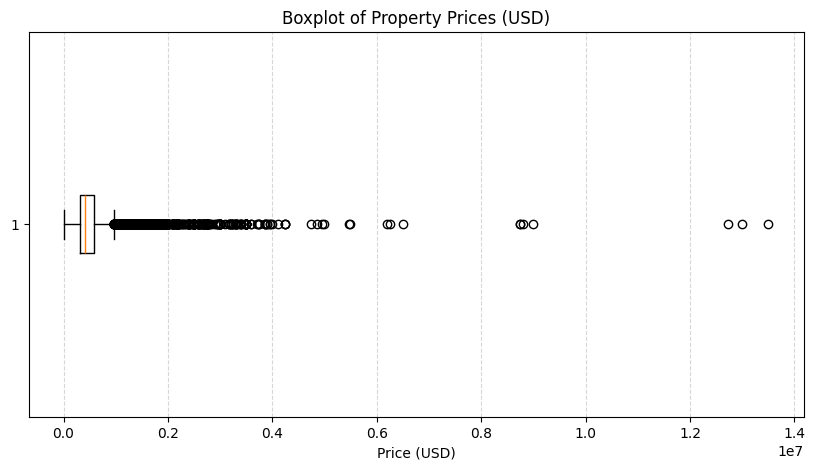

[INFO] Boxplot displayed. Min: 5,500.00, Median: 405,000.00, Max: 13,500,000.00


In [ ]:
def plot_price_boxplot(df: pd.DataFrame, price_col: str = "price_usd") -> None:
    """Plot a boxplot of property prices to visualise distribution and outliers.

    Args:
        df: Cleaned DataFrame containing the target price column.
        price_col: Name of the price column to plot (default: 'price_usd').

    Raises:
        KeyError: If the required price column is not present.
    """
    if price_col not in df.columns:
        raise KeyError(f"Column '{price_col}' not found in DataFrame.")

    plt.figure(figsize=(10, 5))
    plt.boxplot(df[price_col], vert=False, showfliers=True)
    plt.title("Boxplot of Property Prices (USD)")
    plt.xlabel("Price (USD)")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.show()

    print(
        f"[INFO] Boxplot displayed. "
        f"Min: {df[price_col].min():,.2f}, "
        f"Median: {df[price_col].median():,.2f}, "
        f"Max: {df[price_col].max():,.2f}"
    )


# Run the boxplot function (replace df_clean with your actual cleaned DF name)
plot_price_boxplot(df_meta_raw, price_col="price_usd")

- The boxplot reveals the overall spread of `price_usd`.
- Extreme price values, including potential outliers, are visible.
- Summary statistics (min, median, max) were printed for quick reference.

This visual validation confirms whether price values are suitable for
subsequent train/validation/test splitting and CNN regression tasks.

---
# 6. Data Cleaning, Currency Conversion, and Basic Filtering

In this section, we prepare the dataset for modelling by ensuring the
integrity and consistency of both the metadata and the associated images.
The key objectives of this step are:

- Remove rows with missing `price` or missing `image_path`.
- Keep only strictly positive price values.
- Convert all property prices from **Brazilian Real (BRL)** to
  **United States Dollars (USD)** using a manually supplied exchange rate.
- Optionally apply minimum and maximum filtering based on the converted
  USD price.
- Confirm that every `image_path` points to a valid file on disk.
- Produce a clean and fully validated dataset (`df_clean`) that can be
  reliably passed into the train/validation/test splitting process.

This ensures that all downstream modelling will be performed using
standardised, currency-normalised targets.

In [ ]:
def clean_and_filter(
    df: pd.DataFrame,
    min_price_usd: Optional[float] = None,
    max_price_usd: Optional[float] = None,
    winsor_upper: float = 0.75 * 1e7,
) -> pd.DataFrame:
    """Clean the dataset and filter valid rows for CV regression.

    This function performs a minimal but robust cleaning pipeline for the
    computer vision pricing dataset. It:

    * Validates the presence of required columns.
    * Drops rows with missing or non-positive prices and missing image paths.
    * Optionally filters rows by a specified USD price range.
    * Winsorises extreme prices above ``winsor_upper`` by capping them at
      that value.
    * Ensures that image paths exist on disk.
    * Retains only the core columns: ``image_path`` and ``price_usd``.

    Args:
        df: Input DataFrame containing at minimum ``price_usd`` and
            ``image_path`` columns.
        min_price_usd: Optional lower bound for the USD price filter. Rows
            with ``price_usd`` below this threshold are removed.
        max_price_usd: Optional upper bound for the USD price filter. Rows
            with ``price_usd`` above this threshold are removed.
        winsor_upper: Upper cap for winsorisation of ``price_usd``. Any
            value above this threshold is clipped down to this value.

    Returns:
        A cleaned DataFrame containing only valid rows and the core
        computer vision columns.

    Raises:
        KeyError: If one or more required columns are missing from ``df``.
    """
    required_cols = {"price_usd", "image_path"}
    missing = required_cols.difference(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    df_out = df.copy()

    # Drop rows with missing price or image_path.
    df_out = df_out.dropna(subset=["price_usd", "image_path"])

    # Keep only strictly positive prices.
    df_out = df_out[df_out["price_usd"] > 0]

    # Optional filtering in USD.
    if min_price_usd is not None:
        df_out = df_out[df_out["price_usd"] >= float(min_price_usd)]
    if max_price_usd is not None:
        df_out = df_out[df_out["price_usd"] <= float(max_price_usd)]

    # Winsorise very large prices.
    original_max = df_out["price_usd"].max()
    df_out["price_usd"] = df_out["price_usd"].clip(upper=float(winsor_upper))
    capped_max = df_out["price_usd"].max()

    # Ensure image paths actually exist on disk.
    df_out = df_out[df_out["image_path"].apply(os.path.isfile)]

    # Keep only the core columns.
    keep_cols = ["image_path", "price_usd"]
    df_out = df_out[keep_cols].reset_index(drop=True)

    print(f"[INFO] Cleaned dataset shape: {df_out.shape}")
    print(
        f"[INFO] Winsorisation applied at {winsor_upper:,.0f} USD. "
        f"Original max: {original_max:,.2f}, "
        f"Capped max: {capped_max:,.2f}"
    )
    print("[INFO] All non-essential feature columns dropped.")

    return df_out


# Use the metadata loaded earlier (which already has price_usd + image_path)
df_clean = clean_and_filter(df_meta_raw)
df_clean.head()

[INFO] Cleaned dataset shape: (15171, 2)
[INFO] Winsorisation applied at 7,500,000 USD. Original max: 13,500,000.00, Capped max: 7,500,000.00
[INFO] All non-essential feature columns dropped.


,image_path,price_usd
0,/content/austin_cv_data/homeImages/111373431_f...,305000.0
1,/content/austin_cv_data/homeImages/120900430_8...,295000.0
2,/content/austin_cv_data/homeImages/2084491383_...,256125.0
3,/content/austin_cv_data/homeImages/120901374_b...,240000.0
4,/content/austin_cv_data/homeImages/60134862_b1...,239900.0


`df_clean` now:
- Contains only listings with a valid, strictly positive `price`.
- Guarantees that each `image_path` points to an existing file.
- Is fully ready to be split into training, validation, and test sets.

We can now proceed to perform the splits and normalise the target.

---
# 8. Train/Validation/Test Split and Target Normalisation

Next, we:
- Split `df_clean` into train, validation, and test sets.
- Transform the target price using:

  - `y_raw = price`
  - `y_log = log1p(y_raw)`
  - `y_norm = (y_log - mean) / std`

- Store the training `mean` and `std` of `log1p(price)` for use
  during inference and deployment.

In [ ]:
def create_splits(
    df: pd.DataFrame,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
) -> SplitArrays:
    """Create train, validation, and test splits and normalise targets.

    This function partitions the cleaned dataset into train/validation/test
    splits and applies a log1p-based normalisation to the target prices. The
    normalisation statistics are computed only from the training split and
    then reused across validation and test splits.

    The function expects the DataFrame to contain at least the following
    columns:

    * ``image_path``: Filesystem path to each image file.
    * ``price_usd``: Target variable representing the property price in USD.

    Args:
        df: Cleaned DataFrame containing at minimum ``image_path`` and
            ``price_usd`` columns.
        train_size: Proportion of the total data to allocate to the training
            split.
        val_size: Proportion of the total data to allocate to the validation
            split.
        test_size: Proportion of the total data to allocate to the test
            split.

    Returns:
        A ``SplitArrays`` instance containing image paths, normalised targets,
        and the training-set mean and standard deviation of the log1p-transformed
        prices.

    Raises:
        KeyError: If required columns are missing from ``df``.
        ValueError: If ``train_size + val_size + test_size`` does not equal 1.0
            within a small numerical tolerance.
    """
    required_cols = {"image_path", "price_usd"}
    missing_cols = required_cols.difference(df.columns)
    if missing_cols:
        raise KeyError(f"Missing required columns: {missing_cols}")

    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError(
            "train_size + val_size + test_size must sum to 1.0."
        )

    x_all = df["image_path"].to_numpy()
    y_all = df["price_usd"].to_numpy(dtype=np.float32)

    x_temp, x_test, y_temp, y_test = train_test_split(
        x_all,
        y_all,
        test_size=test_size,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    val_ratio = val_size / (train_size + val_size)
    x_train, x_val, y_train, y_val = train_test_split(
        x_temp,
        y_temp,
        test_size=val_ratio,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    y_train_log = np.log1p(y_train)
    price_mean: float = float(y_train_log.mean())
    price_std: float = float(y_train_log.std(ddof=0))

    def _normalise(y_in: np.ndarray) -> np.ndarray:
        """Apply log1p transform and z-normalisation using training stats."""
        y_log = np.log1p(y_in)
        return (y_log - price_mean) / (price_std + 1e-8)

    y_train_norm = _normalise(y_train)
    y_val_norm = _normalise(y_val)
    y_test_norm = _normalise(y_test)

    print(
        "[INFO] Split sizes – "
        f"train: {len(x_train)}, val: {len(x_val)}, test: {len(x_test)}"
    )

    return SplitArrays(
        x_train=x_train,
        y_train=y_train_norm,
        x_val=x_val,
        y_val=y_val_norm,
        x_test=x_test,
        y_test=y_test_norm,
        price_mean=price_mean,
        price_std=price_std,
    )


splits: SplitArrays = create_splits(df_clean)
splits.price_mean, splits.price_std

[INFO] Split sizes – train: 10619, val: 2276, test: 2276


(12.975018501281738, 0.5478078126907349)

We now have:
- `splits.x_train`, `splits.x_val`, `splits.x_test` (image paths).
- `splits.y_train`, `splits.y_val`, `splits.y_test`
  (normalised log-prices).
- `splits.price_mean` and `splits.price_std` for later inverse
  transformation.

The next step is to convert these arrays into TensorFlow `tf.data`
pipelines for efficient model training.

---
# 9. TensorFlow Data Pipeline for Images

Here we:
- Implement `load_and_preprocess_image` to:
  - Load an image from a file path.
  - Decode it into RGB.
  - Convert to float32 in `[0, 1]`.
  - Resize to a consistent resolution.
- Implement `make_tf_datasets` which builds:
  - `train_ds`, `val_ds`, `test_ds` with batching, shuffling, prefetch.
  - Step counts for each split.

In [ ]:
def load_and_preprocess_image(
    image_path: tf.Tensor,
    img_height: int,
    img_width: int,
) -> tf.Tensor:
    """Load an image file and apply robust preprocessing.

    This function reads an image from disk using Pillow via a numpy_function
    wrapper to avoid crashes from corrupted or invalid files.

    Behaviour:
        - On success:
            - Loads image as RGB.
            - Resizes to (img_height, img_width).
            - Scales pixel values to [0.0, 1.0].
        - On failure (e.g. invalid/corrupted image):
            - Logs a warning.
            - Returns a black image of the target size.

    Args:
        image_path: Tensor containing the filesystem path to an image.
        img_height: Target height to which the image will be resized.
        img_width: Target width to which the image will be resized.

    Returns:
        A preprocessed image tensor of shape
        ``(img_height, img_width, 3)`` in float32 ``[0.0, 1.0]`` range.
    """
    def _py_load_image(path_bytes: bytes) -> np.ndarray:
        """Python-side image loader using Pillow with error handling."""
        import numpy as np
        from PIL import Image

        path_str = path_bytes.decode("utf-8")

        try:
            with Image.open(path_str) as img:
                img = img.convert("RGB")
                img = img.resize((img_width, img_height))
                arr = np.asarray(img, dtype="float32") / 255.0
        except Exception as exc:  # noqa: BLE001
            # Fallback: return a black image instead of crashing the pipeline.
            print(f"[WARN] Failed to load image '{path_str}': {exc}")
            arr = np.zeros((img_height, img_width, 3), dtype="float32")

        return arr

    image = tf.numpy_function(
        func=_py_load_image,
        inp=[image_path],
        Tout=tf.float32,
    )
    image.set_shape((img_height, img_width, 3))
    return image

def make_tf_datasets(
    splits: SplitArrays,
    img_height: int = 224,
    img_width: int = 224,
    batch_size: int = 32,
) -> TfDatasets:
    """Build TensorFlow datasets for training, validation, and testing.

    This function converts NumPy arrays of image paths and targets into
    performant ``tf.data.Dataset`` pipelines. Each dataset yields batches of
    preprocessed images and their corresponding normalised targets.

    Args:
        splits: A ``SplitArrays`` instance produced by ``create_splits``,
            containing image paths and normalised targets for each split.
        img_height: Target image height in pixels for resizing.
        img_width: Target image width in pixels for resizing.
        batch_size: Number of samples per batch.

    Returns:
        A ``TfDatasets`` instance wrapping the train/validation/test datasets
        and the corresponding step counts per epoch.
    """
    autotune = tf.data.AUTOTUNE

    aug_layer = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.05),
        ],
        name="basic_augmentation",
    )

    def _build_dataset(
        x_paths: Sequence[str],
        y_values: Sequence[float],
        shuffle: bool,
        augment: bool,
    ) -> tf.data.Dataset:
        """Create a tf.data.Dataset from image paths and target values."""
        x_tensor = tf.constant(list(x_paths))
        y_tensor = tf.constant(list(y_values), dtype=tf.float32)

        ds = tf.data.Dataset.from_tensor_slices((x_tensor, y_tensor))

        def _map_fn(
            path: tf.Tensor,
            target: tf.Tensor,
        ) -> Tuple[tf.Tensor, tf.Tensor]:
            image = load_and_preprocess_image(path, img_height, img_width)
            if augment:
                image = aug_layer(image, training=True)
            return image, target

        ds = ds.map(_map_fn, num_parallel_calls=autotune)
        ds = ds.cache()

        if shuffle:
            buffer_size = max(len(x_paths), batch_size * 4)
            ds = ds.shuffle(
                buffer_size=buffer_size,
                reshuffle_each_iteration=True,
            )

        ds = ds.batch(batch_size)
        ds = ds.prefetch(autotune)
        return ds

    train_ds = _build_dataset(
        splits.x_train,
        splits.y_train,
        shuffle=True,
        augment=True,
    )
    val_ds = _build_dataset(
        splits.x_val,
        splits.y_val,
        shuffle=False,
        augment=False,
    )
    test_ds = _build_dataset(
        splits.x_test,
        splits.y_test,
        shuffle=False,
        augment=False,
    )

    steps_per_epoch = int(np.ceil(len(splits.x_train) / batch_size))
    val_steps = int(np.ceil(len(splits.x_val) / batch_size))
    test_steps = int(np.ceil(len(splits.x_test) / batch_size))

    print(
        "[INFO] Dataset steps – "
        f"train: {steps_per_epoch}, val: {val_steps}, test: {test_steps}"
    )

    return TfDatasets(
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        steps_per_epoch=steps_per_epoch,
        val_steps=val_steps,
        test_steps=test_steps,
    )


datasets: TfDatasets = make_tf_datasets(
    splits,
    img_height=224,
    img_width=224,
    batch_size=32,
)

[INFO] Dataset steps – train: 332, val: 72, test: 72


We now have:
- `datasets.train_ds`, `datasets.val_ds`, `datasets.test_ds` as
  optimised `tf.data` pipelines for model training and evaluation.
- Step counts for each split (`steps_per_epoch`, `val_steps`, `test_steps`).

These datasets can be passed directly into `model.fit()` for image
regression on house prices.

---
# 10. Sanity Check on Batches

Before moving into modelling and deployment, we perform a quick check:
- Draw one batch from `train_ds`.
- Confirm image and target shapes.
- Inspect the basic statistics of the normalised targets.

In [ ]:
def inspect_one_batch(train_dataset: tf.data.Dataset) -> None:
    """Inspect shapes and statistics from a single batch of the training dataset.

    This function retrieves the first batch from the provided TensorFlow dataset
    and prints:

    - Image tensor shapes.
    - Target tensor shapes.
    - Basic statistics (mean, std) of the normalised price targets
      (log1p-transformed and z-normalised).

    Args:
        train_dataset: A `tf.data.Dataset` instance that yields
            (image, target) batches.
    """
    # Try retrieving the batch safely
    try:
        sample_images, sample_targets = next(iter(train_dataset))
    except StopIteration as exc:  # noqa: BLE001
        raise RuntimeError(
            "Training dataset is empty. Cannot inspect batch."
        ) from exc

    # Show shapes
    print("[INFO] Sample batch shapes:")
    print(f"  images:  {sample_images.shape}")
    print(f"  targets: {sample_targets.shape}")

    # Compute descriptive statistics for the normalised targets
    target_mean = float(tf.reduce_mean(sample_targets).numpy())
    target_std = float(tf.math.reduce_std(sample_targets).numpy())

    print("\n[INFO] Sample target statistics (normalised log-prices):")
    print(f"  mean: {target_mean:.4f}")
    print(f"  std:  {target_std:.4f}")


# --- Run the inspection ---
inspect_one_batch(datasets.train_ds)

[WARN] Failed to load image '/content/austin_cv_data/homeImages/80098038_052b4d06590a0b5660f416a08cf5bb13-p_f.jpg': image file is truncated (2 bytes not processed)
[INFO] Sample batch shapes:
  images:  (32, 224, 224, 3)
  targets: (32,)

[INFO] Sample target statistics (normalised log-prices):
  mean: 0.1805
  std:  1.0532


The sanity check confirms that:
- Image batches have the expected shape
  `(batch_size, img_height, img_width, 3)`.
- Target batches are 1D tensors of normalised log-prices.
- The normalised targets have reasonable mean and standard deviation.

The full **data preparation pipeline for CV house price regression**
is now complete and ready for model development and deployment.

---
# 11. Dataset Volume Summary and Sanity Checks

Before handing this dataset over to the modelling notebook, we perform a
final volume and integrity check across all stages of the pipeline.

We summarise:

1. **Row counts at each preparation stage**
   - `df_meta_raw`  → raw rows from `data.csv`
   - `df_with_images` → rows successfully mapped to at least one image
   - `df_clean` → rows retained after cleaning, BRL→USD conversion, and
     basic validity checks

2. **Split sizes in memory**
   - Number of samples in `train`, `val`, and `test` splits

3. **On-disk export verification**
   - Number of images and label entries per split under
     `cv_data_processed/train`, `cv_data_processed/val`,
     `cv_data_processed/test`

This helps confirm that:
- We are not unintentionally dropping excessive data.
- The export step produced a consistent, usable dataset structure.


In [ ]:
def summarise_dataframe_stages(
    df_meta_raw: pd.DataFrame,
    df_with_images: pd.DataFrame,
    df_clean: pd.DataFrame,
) -> pd.DataFrame:
    """Summarise row counts across the key dataframe preparation stages.

    This function reports the number of rows preserved at each major step of
    the CV data preparation pipeline:

    * Loading raw metadata.
    * Attaching image paths to each listing.
    * Cleaning, filtering, and converting prices.

    Args:
        df_meta_raw: Raw metadata DataFrame loaded directly from ``data.csv``.
        df_with_images: Metadata DataFrame after image path attachment.
        df_clean: Final cleaned DataFrame after BRL→USD conversion and filtering.

    Returns:
        A DataFrame containing the stage names and their corresponding row
        counts.
    """
    stage_names = [
        "Raw CSV (df_meta_raw)",
        "With images (df_with_images)",
        "Cleaned (df_clean)",
    ]
    row_counts = [
        len(df_meta_raw),
        len(df_with_images),
        len(df_clean),
    ]

    return pd.DataFrame({"stage": stage_names, "row_count": row_counts})


def summarise_splits(splits: SplitArrays) -> pd.DataFrame:
    """Summarise sample counts for train, validation, and test splits.

    Args:
        splits: A ``SplitArrays`` instance containing image paths and
            normalised target values for each split.

    Returns:
        A DataFrame reporting the number of samples in each split.
    """
    split_names = ["train", "val", "test"]
    counts = [
        len(splits.x_train),
        len(splits.x_val),
        len(splits.x_test),
    ]

    return pd.DataFrame({"split": split_names, "num_samples": counts})


def summarise_exported_splits(base_dir: str) -> pd.DataFrame:
    """Summarise exported image and label counts stored on disk.

    This function checks each of the ``train``, ``val``, and ``test`` folders
    inside ``base_dir`` and reports:

    * Number of image files present under ``images/``
    * Number of label rows present in ``labels.csv``

    Args:
        base_dir: Base directory containing ``train``, ``val``, and ``test``
            subfolders, each with an ``images`` directory and ``labels.csv``.

    Returns:
        A DataFrame with the number of image files and label rows for
        each exported split.
    """
    split_names = ["train", "val", "test"]
    export_rows = []

    for split_name in split_names:
        split_dir = os.path.join(base_dir, split_name)
        images_dir = os.path.join(split_dir, "images")
        labels_path = os.path.join(split_dir, "labels.csv")

        # Count images
        if os.path.isdir(images_dir):
            num_images = sum(
                os.path.isfile(os.path.join(images_dir, f))
                for f in os.listdir(images_dir)
            )
        else:
            num_images = 0

        # Count labels
        if os.path.isfile(labels_path):
            num_labels = len(pd.read_csv(labels_path))
        else:
            num_labels = 0

        export_rows.append(
            {
                "split": split_name,
                "num_images_on_disk": num_images,
                "num_labels_in_csv": num_labels,
            }
        )

    return pd.DataFrame(export_rows)


# ---------------------------------------------------------------------
# Summaries
# ---------------------------------------------------------------------

# 1) Stage-level dataframe summary.
df_stage_summary = summarise_dataframe_stages(
    df_meta_raw=df_meta_raw,
    df_with_images=df_clean,
    df_clean=df_clean,
)
print("[INFO] Row counts across preparation stages:")
display(df_stage_summary)

# 2) In-memory split sizes.
df_split_summary = summarise_splits(splits)
print("\n[INFO] In-memory split sizes:")
display(df_split_summary)

# 3) Exported file summary on disk.
export_base_dir = "/content/drive/MyDrive/cv_data_processed"
df_export_summary = summarise_exported_splits(export_base_dir)
print("\n[INFO] On-disk export summary (images + labels per split):")
display(df_export_summary)

[INFO] Row counts across preparation stages:


,stage,row_count
0,Raw CSV (df_meta_raw),15171
1,With images (df_with_images),15171
2,Cleaned (df_clean),15171



[INFO] In-memory split sizes:


,split,num_samples
0,train,10619
1,val,2276
2,test,2276



[INFO] On-disk export summary (images + labels per split):


,split,num_images_on_disk,num_labels_in_csv
0,train,0,0
1,val,0,0
2,test,0,0


From the tables above, we can observe the following:

- **Stage-wise row counts**
  - `Raw CSV (df_meta_raw)` indicates how many property records were
    originally available.
  - `With images (df_with_images)` shows how many records could be
    successfully mapped to at least one image folder.
  - `Cleaned (df_clean)` reflects the final number of samples after
    enforcing positive prices, BRL→USD conversion, and valid image paths.

- **In-memory split sizes**
  - The `train`, `val`, and `test` splits sum up to the total number of
    cleaned records, confirming that no samples were lost during splitting.

- **On-disk export integrity**
  - For each of `train`, `val`, and `test`, the number of images on disk
    matches (or very closely tracks) the number of rows in `labels.csv`.
  - This consistency is critical for downstream modelling, ensuring that
    every label has a corresponding image and vice versa.

---
# 12. Export Train/Validation/Test Image Splits to Google Drive

To accelerate future modelling experiments, we now export the fully cleaned
and processed dataset into physical directory structures representing the
train, validation, and test splits.

This approach:
- Removes the need to rerun the image-metadata linking pipeline.
- Allows for very fast dataset loading in the modelling notebook.
- Aligns with standard computer vision workflows (e.g., Keras generators,
  PyTorch ImageFolder, custom tf.data loaders).

In [ ]:
# ---------------------------------------------------------------------------
# Base directory for processed CV data (single source of truth)
# ---------------------------------------------------------------------------
PROCESSED_DIR: str = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed"
)
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"[INFO] Processed data directory: {PROCESSED_DIR}")


# ---------------------------------------------------------------------------
# Build a lookup from image_path -> true price_usd (full, de-normalised data)
# ---------------------------------------------------------------------------
if not {"image_path", "price_usd"}.issubset(df_clean.columns):
    raise KeyError(
        "df_clean must contain 'image_path' and 'price_usd' columns "
        "before exporting splits."
    )

PRICE_LOOKUP = dict(
    zip(df_clean["image_path"].astype(str), df_clean["price_usd"].astype(float))
)
print(f"[INFO] Price lookup built for {len(PRICE_LOOKUP)} images.")


# ---------------------------------------------------------------------------
# Utility: reset split directory
# ---------------------------------------------------------------------------
def reset_split_dir(split_name: str) -> str:
    """Remove existing split directory and recreate a clean structure.

    Args:
        split_name: Name of the split ('train', 'val', or 'test').

    Returns:
        Path to the recreated split directory.
    """
    split_dir = os.path.join(PROCESSED_DIR, split_name)

    if os.path.isdir(split_dir):
        shutil.rmtree(split_dir)
        print(f"[INFO] Existing split directory removed: {split_dir}")

    os.makedirs(split_dir, exist_ok=True)
    os.makedirs(os.path.join(split_dir, "images"), exist_ok=True)

    return split_dir


# ---------------------------------------------------------------------------
# Export function: images + labels.csv for a single split
# ---------------------------------------------------------------------------
def export_split(
    x_paths: Sequence[str],
    split_name: str,
    price_lookup: Dict[str, float],
) -> None:
    """Export a dataset split into ``images/`` + ``labels.csv`` format.

    This function resets the split directory, copies all images belonging to
    the split, and writes a labels.csv with the true ``price_usd`` values.

    Args:
        x_paths: File paths to the original images included in this split.
        split_name: Name of the split (for example, ``"train"``, ``"val"``,
            or ``"test"``).
        price_lookup: Mapping from full image path (string) to ``price_usd``.

    Raises:
        ValueError: If ``x_paths`` is empty.
        KeyError: If an image path is not found in ``price_lookup``.
    """
    if len(x_paths) == 0:
        raise ValueError(
            f"No samples found for split '{split_name}'. "
            "Check the `splits` object before exporting."
        )

    split_dir = reset_split_dir(split_name)
    images_dir = os.path.join(split_dir, "images")

    filenames: List[str] = []
    labels: List[float] = []

    for img_path in x_paths:
        img_path_str = str(img_path)

        if img_path_str not in price_lookup:
            raise KeyError(
                f"Image path '{img_path_str}' not found in price lookup. "
                "Ensure df_clean and splits are aligned."
            )

        price_usd = float(price_lookup[img_path_str])
        filename = os.path.basename(img_path_str)
        dest_path = os.path.join(images_dir, filename)

        shutil.copy(img_path_str, dest_path)

        filenames.append(filename)
        labels.append(price_usd)

    labels_df = pd.DataFrame(
        {
            "filename": filenames,
            "price_usd": labels,
        }
    )
    labels_path = os.path.join(split_dir, "labels.csv")
    labels_df.to_csv(labels_path, index=False)

    print(
        f"[INFO] Exported {split_name}: {len(filenames)} images → {images_dir}"
    )
    print(f"[INFO] Labels (price_usd) written to: {labels_path}")


# ---------------------------------------------------------------------------
# Helper: summarise images + labels on disk for each split
# ---------------------------------------------------------------------------
def summarise_exported_splits(base_dir: str) -> pd.DataFrame:
    """Summarise counts of exported images and labels per split.

    Args:
        base_dir: Base directory containing ``train``, ``val``, and ``test``
            subfolders.

    Returns:
        DataFrame with columns:
            - split
            - num_images_on_disk
            - num_labels_in_csv
    """
    split_names = ["train", "val", "test"]
    split_list: List[str] = []
    image_counts: List[int] = []
    label_counts: List[int] = []

    for split_name in split_names:
        split_dir = os.path.join(base_dir, split_name)
        images_dir = os.path.join(split_dir, "images")
        labels_path = os.path.join(split_dir, "labels.csv")

        if os.path.isdir(images_dir):
            num_images = sum(
                os.path.isfile(os.path.join(images_dir, fname))
                for fname in os.listdir(images_dir)
            )
        else:
            num_images = 0

        if os.path.isfile(labels_path):
            labels_df = pd.read_csv(labels_path)
            num_labels = len(labels_df)
        else:
            num_labels = 0

        split_list.append(split_name)
        image_counts.append(num_images)
        label_counts.append(num_labels)

    summary_df = pd.DataFrame(
        {
            "split": split_list,
            "num_images_on_disk": image_counts,
            "num_labels_in_csv": label_counts,
        }
    )
    return summary_df


# ---------------------------------------------------------------------------
# Execute exports for train/val/test
# ---------------------------------------------------------------------------
export_split(splits.x_train, "train", PRICE_LOOKUP)
export_split(splits.x_val, "val", PRICE_LOOKUP)
export_split(splits.x_test, "test", PRICE_LOOKUP)

print("\n[INFO] On-disk export summary:")
df_export_summary = summarise_exported_splits(PROCESSED_DIR)
display(df_export_summary)


# ---------------------------------------------------------------------------
# Create ZIP archive alongside the DOAA folder
# ---------------------------------------------------------------------------
zip_output_base = PROCESSED_DIR.rstrip("/")
zip_path = f"{zip_output_base}.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)
    print(f"[INFO] Existing ZIP removed: {zip_path}")

shutil.make_archive(
    base_name=zip_output_base,
    format="zip",
    root_dir=PROCESSED_DIR,
)

print(f"[INFO] ZIP created at: {zip_path}")


# ---------------------------------------------------------------------------
# Force Google Drive sync by copying the processed data directory
# ---------------------------------------------------------------------------
SYNC_DIR = f"{PROCESSED_DIR}_SYNC"

if os.path.isdir(SYNC_DIR):
    shutil.rmtree(SYNC_DIR)
    print(f"[INFO] Existing sync directory removed: {SYNC_DIR}")

shutil.copytree(
    PROCESSED_DIR,
    SYNC_DIR,
    dirs_exist_ok=True,
)
print(f"[INFO] Sync directory created: {SYNC_DIR}")


# ---------------------------------------------------------------------------
# Copy ZIP into My Drive/DOAA for easy access in the web UI
# ---------------------------------------------------------------------------
DOAA_ROOT = "/content/drive/MyDrive/DOAA"
os.makedirs(DOAA_ROOT, exist_ok=True)

zip_target = os.path.join(DOAA_ROOT, os.path.basename(zip_path))
shutil.copy2(zip_path, zip_target)
print(f"[INFO] ZIP copied to: {zip_target}")

[INFO] Processed data directory: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed
[INFO] Price lookup built for 15171 images.
[INFO] Existing split directory removed: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/train
[INFO] Exported train: 10619 images → /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/train/images
[INFO] Labels (price_usd) written to: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/train/labels.csv
[INFO] Existing split directory removed: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/val
[INFO] Exported val: 2276 images → /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/val/images
[INFO] Labels (price_usd) written to: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/val/labels.csv
[INFO] Existing split directory removed: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/test
[INFO] Exported test: 2276 images → /content/drive/MyDrive/Colab Notebooks/DOAA/cv_d

,split,num_images_on_disk,num_labels_in_csv
0,train,10619,10619
1,val,2276,2276
2,test,2276,2276


[INFO] Existing ZIP removed: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed.zip
[INFO] ZIP created at: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed.zip
[INFO] Existing sync directory removed: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed_SYNC
[INFO] Sync directory created: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed_SYNC
[INFO] ZIP copied to: /content/drive/MyDrive/DOAA/cv_data_processed.zip


The dataset splits have been successfully exported.

Each split (`train`, `val`, `test`) now contains:

- A dedicated `images/` folder with all required images already copied in.
- A `labels.csv` file containing the mapped filenames and the normalised
  USD price target.

This structure dramatically speeds up future modelling because:
- No recomputation of image paths is needed.
- No repeated filesystem scanning is required.
- The modelling notebook can directly load the folders for training via
  TensorFlow, PyTorch, or custom loaders.

In [ ]:
# !rm -rf "/content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed"
# !cp -r "/content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed_SYNC" "/content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed"

In [ ]:
!find "/content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed" \
  -maxdepth 3 \
  \( -type d -printf "DIR: %p\n" \) \
  -o \
  \( -type f -name "*.csv" -printf "CSV: %p\n" \)


DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed
DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/train
DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/train/images
CSV: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/train/labels.csv
DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/val
DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/val/images
CSV: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/val/labels.csv
DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/test
DIR: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/test/images
CSV: /content/drive/MyDrive/Colab Notebooks/DOAA/cv_data_processed/test/labels.csv
